In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 4.7 MB/s eta 0:00:09
   - -------------------------------------- 1.8/40.2 MB 5.1 MB/s eta 0:00:08
   -- ------------------------------------- 2.9/40.2 MB 5.4 MB/s eta 0:00:07
   --- ------------------------------------ 3.9/40.2 MB 5.1 MB/s eta 0:00:08
   ---- ----------------------------------- 4.7/40.2 MB 4.9 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/40.2 MB 4.7 MB/s eta 0:00:08
   ------ --------------------------------- 6.6/40.2 MB 4.7 MB/s eta 0:00:08
   ------- -------------------------------- 7.3/40.2 MB 4.6 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/40.2 MB 4.6 MB/s eta 0:00:07
   --------- ------------------------------ 9.2/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 10.7/40.2 MB 4.5 MB/s eta 0:00:07
   -

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:",cv2.__version__)
print("NumPy Version:",np.__version__)

OpenCV Version: 4.13.0
NumPy Version: 2.1.3


In [4]:
import os
import pandas as pd

dataset_path="dataset"

files=os.listdir(dataset_path)

df=pd.DataFrame(files,columns=["filename"])

df.head()

,filename
0,100_0_0_20170112213500903.jpg.chip.jpg
1,100_0_0_20170112215240346.jpg.chip.jpg
2,100_1_0_20170110183726390.jpg.chip.jpg
3,100_1_0_20170112213001988.jpg.chip.jpg
4,100_1_0_20170112213303693.jpg.chip.jpg


In [5]:
len(df)

23708

In [6]:
df["age"]=df["filename"].apply(lambda x: int(x.split("_")[0]))
df["gender"]=df["filename"].apply(lambda x: int(x.split("_")[1]))

df.head()

,filename,age,gender
0,100_0_0_20170112213500903.jpg.chip.jpg,100,0
1,100_0_0_20170112215240346.jpg.chip.jpg,100,0
2,100_1_0_20170110183726390.jpg.chip.jpg,100,1
3,100_1_0_20170112213001988.jpg.chip.jpg,100,1
4,100_1_0_20170112213303693.jpg.chip.jpg,100,1


In [7]:
print(df["age"].head())
print(df["gender"].head())

0    100
1    100
2    100
3    100
4    100
Name: age, dtype: int64
0    0
1    0
2    1
3    1
4    1
Name: gender, dtype: int64


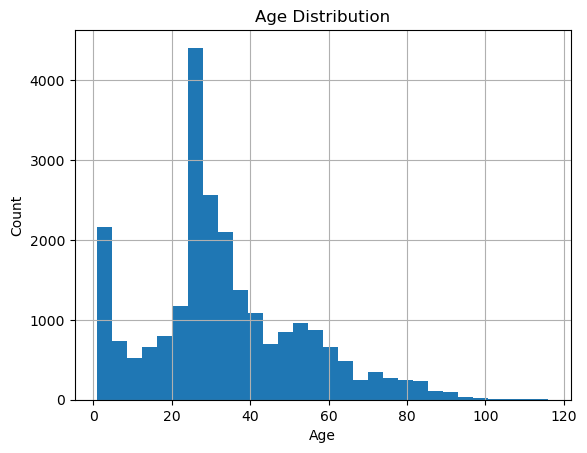

In [10]:
import matplotlib.pyplot as plt

df["age"].hist(bins=30)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

import os
os.makedirs("images",exist_ok=True)
plt.savefig(
    "images/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [9]:
df["gender"].value_counts()

gender
0    12391
1    11317
Name: count, dtype: int64

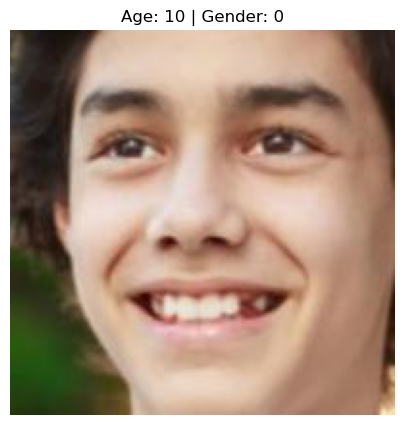

In [12]:
sample=df.iloc[100]
img_path="dataset/"+sample["filename"]
img=cv2.imread(img_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(
    f"Age: {sample['age']} | Gender: {sample['gender']}"
)
plt.axis("off")
plt.show()

In [13]:
img.shape

(200, 200, 3)

In [19]:
print(img[0,0])
print(img.dtype)

[73 63 53]
uint8


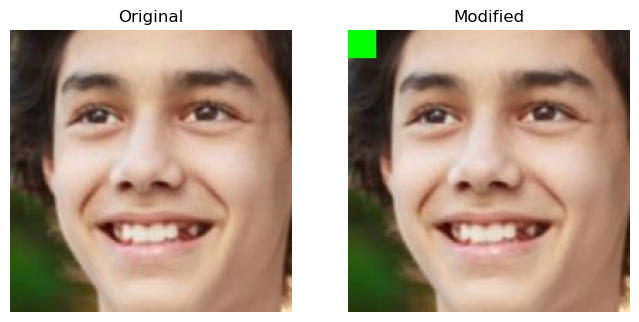

In [22]:
modified=img.copy()

modified[0:20,0:20]=[0,255,0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(modified)
plt.title("Modified")
plt.axis("off")

plt.show()